In [1]:
import subprocess
import sys, os

#### If running on ROOT casa image some packages necessary for opening our files and plotting are not installed

def install_package(package_name):
    # Install the package using subprocess to call pip
    subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

def import_packages():
    try:
        import mplhep  # Replace with the module name of the package
    except ImportError:
        print(f"{'mplhep'} not found. Installing...")
        install_package("mplhep")
        import mplhep  # Import again after installation
    try:
        import hist  # Replace with the module name of the package
    except ImportError:
        print(f"{'hist'} not found. Installing...")
        install_package("hist")
        import hist  # Import again after installation
        
        
import_packages()

In [2]:
import pickle as pkl
import numpy as np 
import hist
from collections import defaultdict
from utils.integrate_and_rebin import *
from tools import binning

In [3]:
prepend = "../coffeaOutput/dijet/"
os.path.isdir(prepend)
filenames = [
    prepend + "dijetHistsTest_addJMRJMSplots_QCD_MG_2016APV_fixfakes2.5.pkl",
    prepend + "dijetHistsTest_fixfakes_QCD_MG_2016_y2.5.pkl",
    prepend + "dijetHistsTest_addJMRJMSplots_QCD_MG_2017_fixfakes2.5.pkl",
    prepend + "dijetHistsTest_addJMRJMSplots_QCD_MG_2018_fixfakes2.5.pkl",
]

filename_herwig = "./inputs/rho/" + "herwig_all.pkl"

In [4]:
def group(h: hist.Hist, oldname: str, newname: str, grouping: dict[str, list[str]]):
    hnew = hist.Hist(
        hist.axis.StrCategory(grouping, name=newname),
        *(ax for ax in h.axes if ax.name != oldname),
        storage=h.storage_type,
    )
    for i, indices in enumerate(grouping.values()):
        hnew.view(flow=True)[i] = h[{oldname: indices}][{oldname: sum}].view(flow=True)

    return hnew

In [5]:
keymap = {
    "2016APV": "QCD_pythiaMG2016APV",
    "2016": "QCD_pythiaMG2016",
    "2017": "QCD_pythiaMG2017",
    "2018": "QCD_pythiaMG2018",
}
#htbin_list = ['pythia_HT-100to200', 'pythia_HT-200to400', 'pythia_HT-400to600', 'pythia_HT-1200to2500', 'pythia_HT-2500toInf', 'pythia_HT-800to1200', 'pythia_HT-600to800']

In [6]:
response_dict = {}
bins = binning.bin_edges(True)
for filename in filenames:
    era = filename.split('_')[4]
    key = keymap[era]
    response_dict.setdefault('u', {})
    response_dict.setdefault('g', {})
    with open(filename, "rb") as f:
        data = pkl.load(f)
        print(data.keys())
        # ensure top-level 'u' and 'g' keys exist
        print(data['response_matrix_rho_u'])
        rebinned_output = rebin_hist(data['response_matrix_rho_u'], 'ptreco', bins.pt_edges)
        rebinned_output = rebin_hist(rebinned_output, 'ptgen', bins.pt_edges)
        rebinned_output = rebin_hist(rebinned_output, 'mpt_reco', bins.rho_edges)
        rebinned_output = rebin_hist(rebinned_output, 'mpt_gen', bins.rho_edges_gen)
        response_dict['u'][key] = rebinned_output.project('dataset', 'ptgen', 'mpt_gen', 'ptreco', 'mpt_reco', 'systematic')
        rebinned_output = rebin_hist(data['response_matrix_rho_g'], 'ptreco', bins.pt_edges)
        rebinned_output = rebin_hist(rebinned_output, 'ptgen', bins.pt_edges)
        rebinned_output = rebin_hist(rebinned_output, 'mpt_reco', bins.rho_edges)
        rebinned_output = rebin_hist(rebinned_output, 'mpt_gen', bins.rho_edges_gen)
        response_dict['g'][key] = rebinned_output.project('dataset', 'ptgen', 'mpt_gen', 'ptreco', 'mpt_reco', 'systematic')

 

dict_keys(['ptjet_mjet_u_reco', 'ptjet_mjet_g_reco', 'ptjet_rhojet_u_reco', 'ptjet_rhojet_g_reco', 'ptjet_mjet_u_gen', 'ptjet_mjet_g_gen', 'ptjet_rhojet_u_gen', 'ptjet_rhojet_g_gen', 'response_matrix_rho_u', 'response_matrix_rho_g', 'response_matrix_u', 'response_matrix_g', 'cutflow', 'jkflow'])
Hist(
  StrCategory(['QCD_pythiaMG2016APV'], growth=True, name='dataset', label='Primary dataset'),
  StrCategory(['nominal', 'PDFUp', 'Q2muRDown', 'PUSFUp', 'PUSFDown', 'PDFDown', 'L1prefiringDown', 'Q2muFUp', 'Q2muRUp', 'L1prefiringUp', 'LuminosityDown', 'LuminosityUp', 'Q2muFDown', 'JERUp', 'JERDown'], growth=True, name='systematic', label='Systematic'),
  IntCategory([-1], growth=True, name='jk', label='Jackknife section'),
  Variable([0, 200, 290, 400, 480, 570, 680, 760, 820, 13000], name='ptreco', label='$p_{T,RECO}$ [GeV]'),
  Variable([0, 200, 290, 400, 480, 570, 680, 760, 820, 13000], name='ptgen', label='$p_{T,GEN}$ [GeV]'),
  Variable(array([-10.  ,  -9.  ,  -8.  ,  -7.5 ,  -7.  ,  

/home/cms-jovyan/GluonJetMass/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/home/cms-jovyan/GluonJetMass/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


dict_keys(['ptjet_mjet_u_reco', 'ptjet_mjet_g_reco', 'ptjet_rhojet_u_reco', 'ptjet_rhojet_g_reco', 'ptjet_mjet_u_gen', 'ptjet_mjet_g_gen', 'ptjet_rhojet_u_gen', 'ptjet_rhojet_g_gen', 'response_matrix_rho_u', 'response_matrix_rho_g', 'response_matrix_u', 'response_matrix_g', 'cutflow', 'jkflow'])
Hist(
  StrCategory(['QCD_pythiaMG2017'], growth=True, name='dataset', label='Primary dataset'),
  StrCategory(['nominal', 'Q2muFDown', 'LuminosityDown', 'Q2muFUp', 'LuminosityUp', 'PUSFUp', 'PDFDown', 'PUSFDown', 'PDFUp', 'Q2muRUp', 'Q2muRDown', 'L1prefiringUp', 'L1prefiringDown', 'JERUp', 'JERDown'], growth=True, name='systematic', label='Systematic'),
  IntCategory([-1], growth=True, name='jk', label='Jackknife section'),
  Variable([0, 200, 290, 400, 480, 570, 680, 760, 820, 13000], name='ptreco', label='$p_{T,RECO}$ [GeV]'),
  Variable([0, 200, 290, 400, 480, 570, 680, 760, 820, 13000], name='ptgen', label='$p_{T,GEN}$ [GeV]'),
  Variable(array([-10.  ,  -9.  ,  -8.  ,  -7.5 ,  -7.  ,  -6.

In [7]:
# grouping = defaultdict(list)
# grouping[new_key].append(ds)
# h = group(h, oldname="dataset", newname="dataset", grouping=dict(grouping))

In [8]:
correlation_dic = {
    'JES_AbsoluteMPFBias': 1,
    'JES_AbsoluteScale': 1,
    'JES_AbsoluteStat': 0,
    'JES_FlavorQCD': 1,
    'JES_Fragmentation': 1,
    'JES_PileUpDataMC': 0.5,
    'JES_PileUpPtBB': 0.5,
    'JES_PileUpPtEC1': 0.5,
    'JES_PileUpPtEC2': 0.5,
    'JES_PileUpPtHF': 0.5,
    'JES_PileUpPtRef': 0.5,
    'JES_RelativeFSR': 0.5,
    'JES_RelativeJEREC1': 0,
    'JES_RelativeJEREC2': 0,
    'JES_RelativeJERHF': 0.5,
    'JES_RelativePtBB': 0.5,
    'JES_RelativePtEC1': 0,
    'JES_RelativePtEC2': 0,
    'JES_RelativePtHF': 0.5,
    'JES_RelativeBal': 0.5,
    'JES_RelativeSample': 0,
    'JES_RelativeStatEC': 0,
    'JES_RelativeStatFSR': 0,
    'JES_RelativeStatHF': 0,
    'JES_SinglePionECAL': 1,
    'JES_SinglePionHCAL': 1,
    'JES_TimePtEta': 0,
    'JER': 0,
}

jes_sys_list = ['JERUp']
# jes_sys_list = ['JES_AbsoluteMPFBiasUp', 'JES_AbsoluteMPFBiasDown', 'JES_AbsoluteScaleUp', 'JES_AbsoluteScaleDown',
#                 'JES_AbsoluteStatUp', 'JES_AbsoluteStatDown', 'JES_FlavorQCDUp', 'JES_FlavorQCDDown', 'JES_FragmentationUp',
#                 'JES_FragmentationDown', 'JES_PileUpDataMCUp', 'JES_PileUpDataMCDown', 'JES_PileUpPtBBUp', 'JES_PileUpPtBBDown',
#                 'JES_PileUpPtEC1Up', 'JES_PileUpPtEC1Down', 'JES_PileUpPtEC2Up', 'JES_PileUpPtEC2Down', 'JES_PileUpPtHFUp', 'JES_PileUpPtHFDown', 
#                 'JES_PileUpPtRefUp', 'JES_PileUpPtRefDown', 'JES_RelativeFSRUp', 'JES_RelativeFSRDown', 'JES_RelativeJEREC1Up',
#                 'JES_RelativeJEREC1Down', 'JES_RelativeJEREC2Up', 'JES_RelativeJEREC2Down', 'JES_RelativeJERHFUp', 'JES_RelativeJERHFDown',
#                 'JES_RelativePtBBUp', 'JES_RelativePtBBDown', 'JES_RelativePtEC1Up', 'JES_RelativePtEC1Down', 'JES_RelativePtEC2Up', 'JES_RelativePtEC2Down',
#                 'JES_RelativePtHFUp', 'JES_RelativePtHFDown', 'JES_RelativeBalUp', 'JES_RelativeBalDown', 'JES_RelativeSampleUp', 'JES_RelativeSampleDown', 
#                 'JES_RelativeStatECUp', 'JES_RelativeStatECDown', 'JES_RelativeStatFSRUp', 'JES_RelativeStatFSRDown', 'JES_RelativeStatHFUp', 'JES_RelativeStatHFDown',
#                 'JES_SinglePionECALUp', 'JES_SinglePionECALDown', 'JES_SinglePionHCALUp', 'JES_SinglePionHCALDown', 'JES_TimePtEtaUp', 'JES_TimePtEtaDown', 'JERUp', 'JERDown']

non_jes_sys_list = ['LuminosityDown', 'PUSFDown', 'Q2muRUp', 'L1prefiringUp', 'Q2muFUp', 'PDFUp', 'PDFDown', 'PUSFUp', 'LuminosityUp', 'L1prefiringDown',  'JERUp']


non_jes_sys_list_up = [sys for sys in non_jes_sys_list if sys[-2:] == 'Up' ]
non_jes_sys_list_down = [sys for sys in non_jes_sys_list if sys[-4:] == 'Down' ]
print(non_jes_sys_list_down)
jes_sys_list_up = [sys for sys in jes_sys_list if sys[-2:] == 'Up' ]
jes_sys_list_down = [sys for sys in jes_sys_list if sys[-4:] == 'Down' ]

['LuminosityDown', 'PUSFDown', 'PDFDown', 'L1prefiringDown']


In [45]:
sys_matrix_dic_up = {}

groomed = False
if not groomed:
    response = response_dict['u']
else:
    response = response_dict['g']

for sys in jes_sys_list_up:
    m_nom_2016 = response[keymap['2016APV']][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values() +\
        response[keymap['2016']][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    m_nom_2017 = response[keymap['2017']][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    m_nom_2018 = response[keymap['2018']][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()

    variance = np.array([response[era][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').variances() for era in list(keymap.values())]).sum(axis = 0)
    
    m_sys_2016 = response[keymap['2016APV']][..., sys].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values() + \
        response[keymap['2016']][..., sys].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    m_sys_2017 = response[keymap['2017']][..., sys].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    m_sys_2018 = response[keymap['2018']][..., sys].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    
    
    m_var_2016 = m_sys_2016 + m_nom_2017 + m_nom_2018
    m_var_2017 = m_nom_2016 + m_sys_2017 + m_nom_2018
    m_var_2018 = m_nom_2016 + m_nom_2017 + m_sys_2018
    
    
    rho = correlation_dic[sys[:-2]] ## correlation factor
    
    sigma_2016 = m_sys_2016 - m_nom_2016
    sigma_2017 = m_sys_2017 - m_nom_2017
    sigma_2018 = m_sys_2018 - m_nom_2018
    
    sigma_corr = rho*sigma_2016 + rho*sigma_2017 + rho*sigma_2018
    
    sigma_uncorr_2016 = (1-rho)*sigma_2016
    sigma_uncorr_2017 = (1-rho)*sigma_2017
    sigma_uncorr_2018 = (1-rho)*sigma_2018
    
    m_nom =  m_nom_2016 + m_nom_2017 + m_nom_2018
    m_corr = m_nom + sigma_corr
    
    m_uncorr_2016 = m_nom + sigma_uncorr_2016
    
    m_uncorr_2017 = m_nom + sigma_uncorr_2017

    m_uncorr_2018 = m_nom + sigma_uncorr_2018

    

    sys_matrix_dic_up[sys+'_corr'] = m_corr
    sys_matrix_dic_up[sys+'_uncorr_2016'] = m_uncorr_2016
    sys_matrix_dic_up[sys+'_uncorr_2017'] = m_uncorr_2017
    sys_matrix_dic_up[sys+'_uncorr_2018'] = m_uncorr_2018
    
non_jes_sys_matrix_dic_up = {}
for sys in non_jes_sys_list_up:
    sys_matrix_dic_up[sys] = response[keymap['2016APV']][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response[keymap['2016']][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response[keymap['2017']][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response[keymap['2018']][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()

    non_jes_sys_matrix_dic_up[sys] = response[keymap['2016APV']][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response[keymap['2016']][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response[keymap['2017']][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response[keymap['2018']][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()



sys_matrix_dic_down = {}
non_jes_sys_matrix_dic_down = {}
for sys in jes_sys_list_down:
    m_nom_2016 = response[keymap['2016APV']][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values() + \
                 response[keymap['2016']][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    m_nom_2017 = response[keymap['2017']][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    m_nom_2018 = response[keymap['2018']][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    
    m_sys_2016 = response[keymap['2016APV']][..., sys].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values() + \
                 response[keymap['2016']][..., sys].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    m_sys_2017 = response[keymap['2017']][..., sys].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    m_sys_2018 = response[keymap['2018']][..., sys].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
    
    
    m_var_2016 = m_sys_2016 + m_nom_2017 + m_nom_2018
    m_var_2017 = m_nom_2016 + m_sys_2017 + m_nom_2018
    m_var_2018 = m_nom_2016 + m_nom_2017 + m_sys_2018
    
    
    rho = correlation_dic[sys[:-4]] ## correlation factor
    
    sigma_2016 = m_sys_2016 - m_nom_2016
    sigma_2017 = m_sys_2017 - m_nom_2017
    sigma_2018 = m_sys_2018 - m_nom_2018
    
    sigma_corr = rho*sigma_2016 + rho*sigma_2017 + rho*sigma_2018
    
    sigma_uncorr_2016 = (1-rho)*sigma_2016
    sigma_uncorr_2017 = (1-rho)*sigma_2017
    sigma_uncorr_2018 = (1-rho)*sigma_2018
    
    m_nom =  m_nom_2016 + m_nom_2017 + m_nom_2018
    m_corr = m_nom + sigma_corr
    
    m_uncorr_2016 = m_nom + sigma_uncorr_2016
    
    m_uncorr_2017 = m_nom + sigma_uncorr_2017

    m_uncorr_2018 = m_nom + sigma_uncorr_2018

    

    sys_matrix_dic_down[sys+'_corr'] = m_corr
    sys_matrix_dic_down[sys+'_uncorr_2016'] = m_uncorr_2016
    sys_matrix_dic_down[sys+'_uncorr_2017'] = m_uncorr_2017
    sys_matrix_dic_down[sys+'_uncorr_2018'] = m_uncorr_2018
    

for sys in non_jes_sys_list_down:
    print(sys)
    sys_matrix_dic_down[sys] = response[keymap['2016APV']][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response[keymap['2016']][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response[keymap['2017']][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response[keymap['2018']][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()
    non_jes_sys_matrix_dic_down[sys] = response[keymap['2016APV']][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response[keymap['2016']][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response[keymap['2017']][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()\
                            + response[keymap['2018']][{'systematic':sys}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()



LuminosityDown
PUSFDown
PDFDown
L1prefiringDown


In [46]:
if not groomed:
    response = response_dict['u']
else:
    response = response_dict['g']
sys_matrix_dic_up['nominal'] = response[keymap['2018']][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values() +\
        response[keymap['2017']][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()  +\
            response[keymap['2016']][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values() +\
                response[keymap['2016APV']][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()
sys_matrix_dic_down['nominal'] = response[keymap['2018']][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values() +\
        response[keymap['2017']][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()  +\
            response[keymap['2016']][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values() +\
                response[keymap['2016APV']][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco').values()

In [47]:
with open(filename_herwig, "rb") as f:
    data_herwig = pkl.load(f)
    if not groomed:
        sys_matrix_dic_up['herwigUp'] = data_herwig['response_matrix_rho_u'][{"systematic":"nominal"}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()
        sys_matrix_dic_down['herwigDown'] = data_herwig['response_matrix_rho_u'][{"systematic":"nominal"}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()
    else:
        sys_matrix_dic_up['herwigUp'] = data_herwig['response_matrix_rho_g'][{"systematic":"nominal"}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()
        sys_matrix_dic_down['herwigDown'] = data_herwig['response_matrix_rho_g'][{"systematic":"nominal"}].project('ptgen','mpt_gen','ptreco','mpt_reco').values()

In [48]:
import os

out_dir = "./inputs/rho/"  # uses the existing "./inputs/" variable
os.makedirs(out_dir, exist_ok=True)
if groomed:
    out_path = os.path.join(out_dir, "sys_matrix_dic_rho_groomed_v2.pkl")
else:
    out_path = os.path.join(out_dir, "sys_matrix_dic_rho_ungroomed_v2.pkl")

# merge up and down into a single dict, avoid double-counting 'nominal'
merged = dict(sys_matrix_dic_up)  # shallow copy of up
for k, v in sys_matrix_dic_down.items():
    if k == "nominal":
        continue  # skip duplicate nominal from the down dict
    if k in merged:
        # if a key collides, store the down version with a suffix
        merged_key = f"{k}_down"
        # ensure uniqueness
        i = 1
        unique_key = merged_key
        while unique_key in merged:
            unique_key = f"{merged_key}_{i}"
            i += 1
        merged[unique_key] = v
    else:
        merged[k] = v
print(merged.keys())
with open(out_path, "wb") as f:
    pkl.dump(merged, f, protocol=4)

print(f"Saved {out_path} with {len(merged)} entries")

dict_keys(['JERUp_corr', 'JERUp_uncorr_2016', 'JERUp_uncorr_2017', 'JERUp_uncorr_2018', 'Q2muRUp', 'L1prefiringUp', 'Q2muFUp', 'PDFUp', 'PUSFUp', 'LuminosityUp', 'JERUp', 'nominal', 'herwigUp', 'LuminosityDown', 'PUSFDown', 'PDFDown', 'L1prefiringDown', 'herwigDown'])
Saved ./inputs/rho/sys_matrix_dic_rho_ungroomed_v2.pkl with 18 entries


In [55]:
sys_matrix_dic_up['JERUp_corr'].sum(axis = (0,1,2)).sum()/sys_matrix_dic_down['herwigDown'].sum(axis = (0,1,2)).sum()
sys_matrix_dic_up['JERUp_corr'].sum(axis = (0,1,2)).sum()/sys_matrix_dic_up['herwigUp'].sum(axis = (0,1,2)).sum()

0.006757725074789203

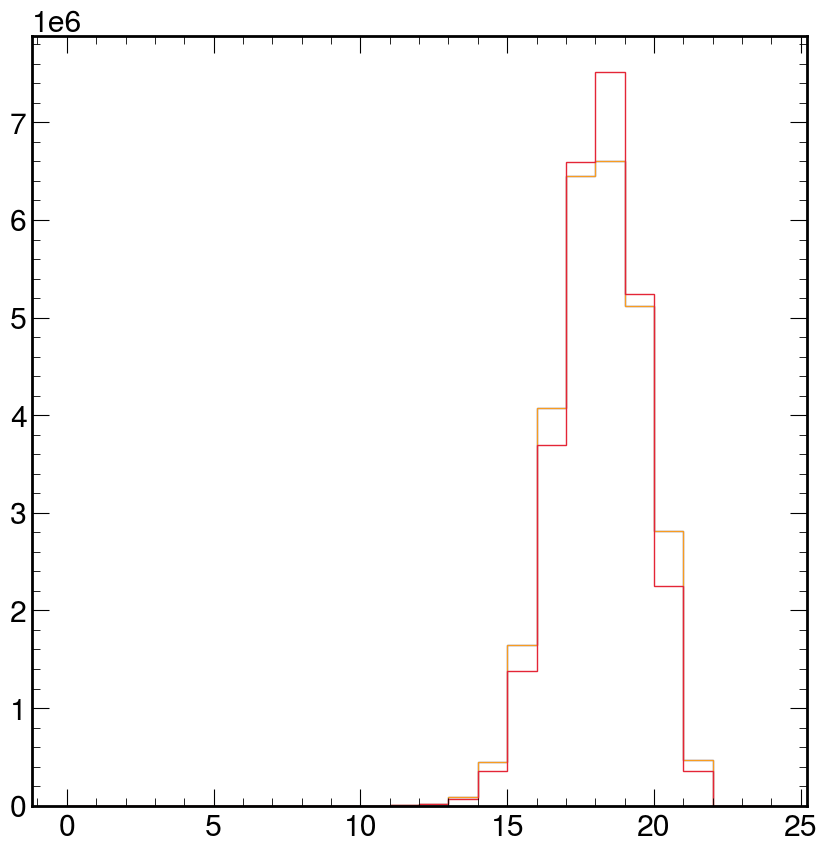

In [50]:
import matplotlib.pyplot as plt
plt.stairs(sys_matrix_dic_up['nominal'].sum(axis = (0,1,2)), label = 'nominal')
plt.stairs(sys_matrix_dic_up['JERUp_corr'].sum(axis = (0,1,2)), label = 'JERUp')
plt.stairs(0.0067*sys_matrix_dic_down['herwigDown'].sum(axis = (0,1,2)), label = 'Down')

dict_keys(['JERUp_corr', 'JERUp_uncorr_2016', 'JERUp_uncorr_2017', 'JERUp_uncorr_2018', 'Q2muRUp', 'L1prefiringUp', 'Q2muFUp', 'PDFUp', 'PUSFUp', 'LuminosityUp', 'JERUp', 'nominal', 'herwigUp'])
dict_keys(['LuminosityDown', 'PUSFDown', 'PDFDown', 'L1prefiringDown', 'nominal', 'herwigDown'])


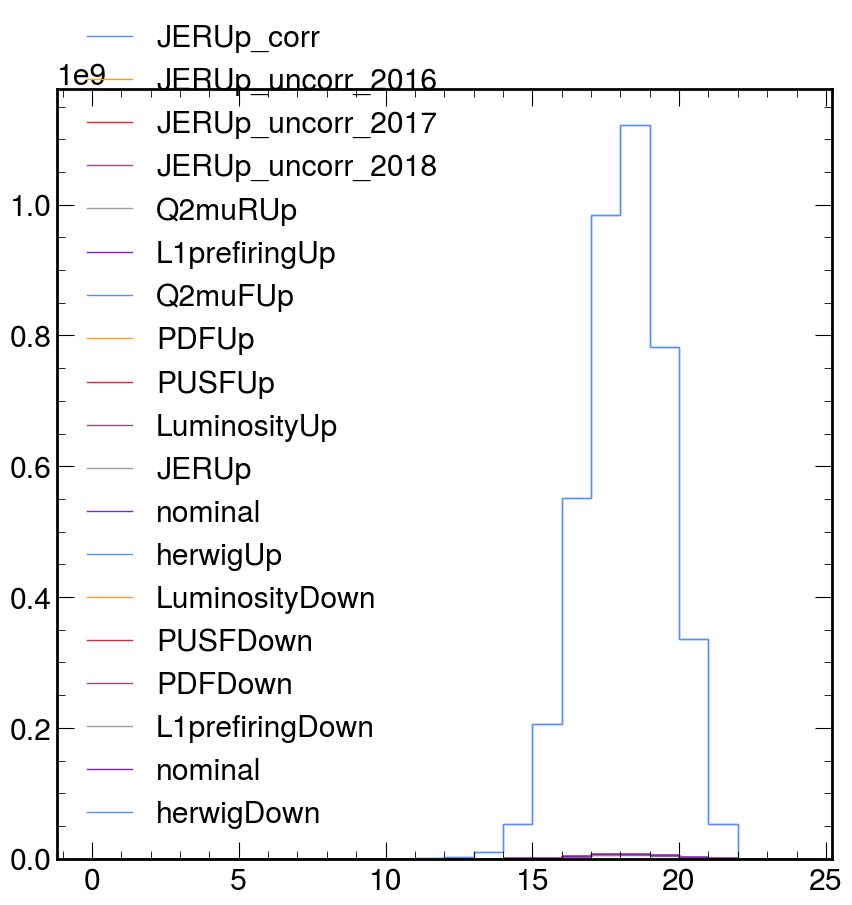

In [51]:

print(sys_matrix_dic_up.keys())
print(sys_matrix_dic_down.keys())
for key in sys_matrix_dic_up.keys():
    plt.stairs(sys_matrix_dic_up[key].sum(axis = (0,1,2)), label=key)
for key in sys_matrix_dic_down.keys():
    plt.stairs(sys_matrix_dic_down[key].sum(axis = (0,1,2)), label=key)
plt.legend()

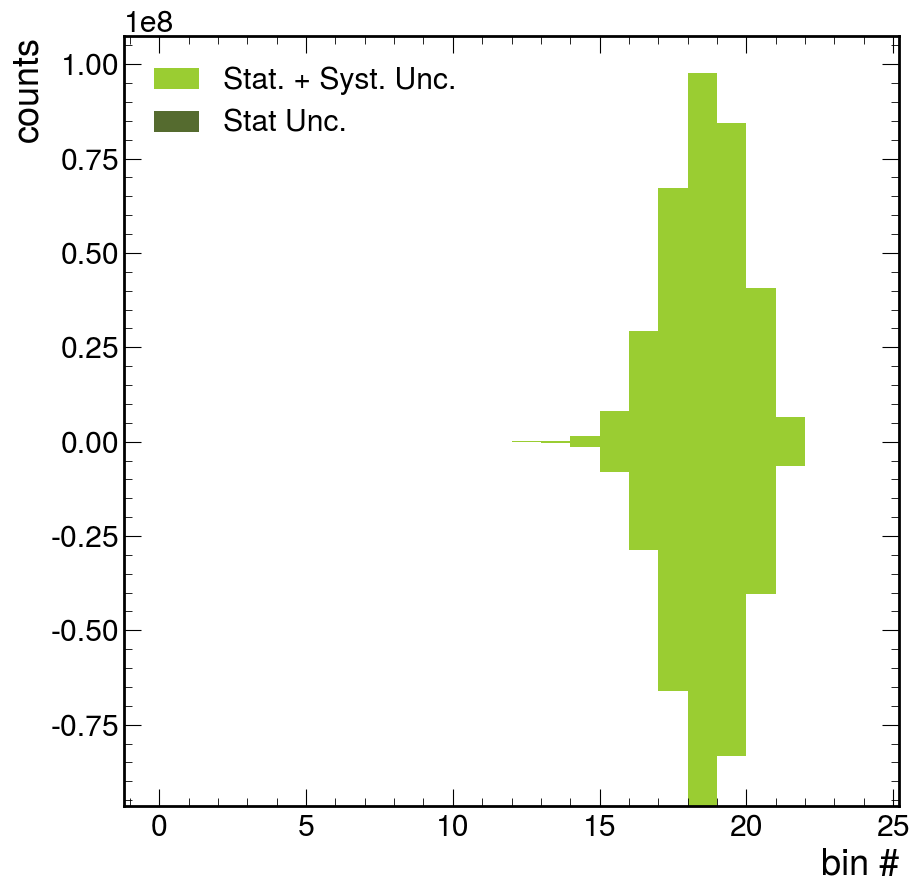

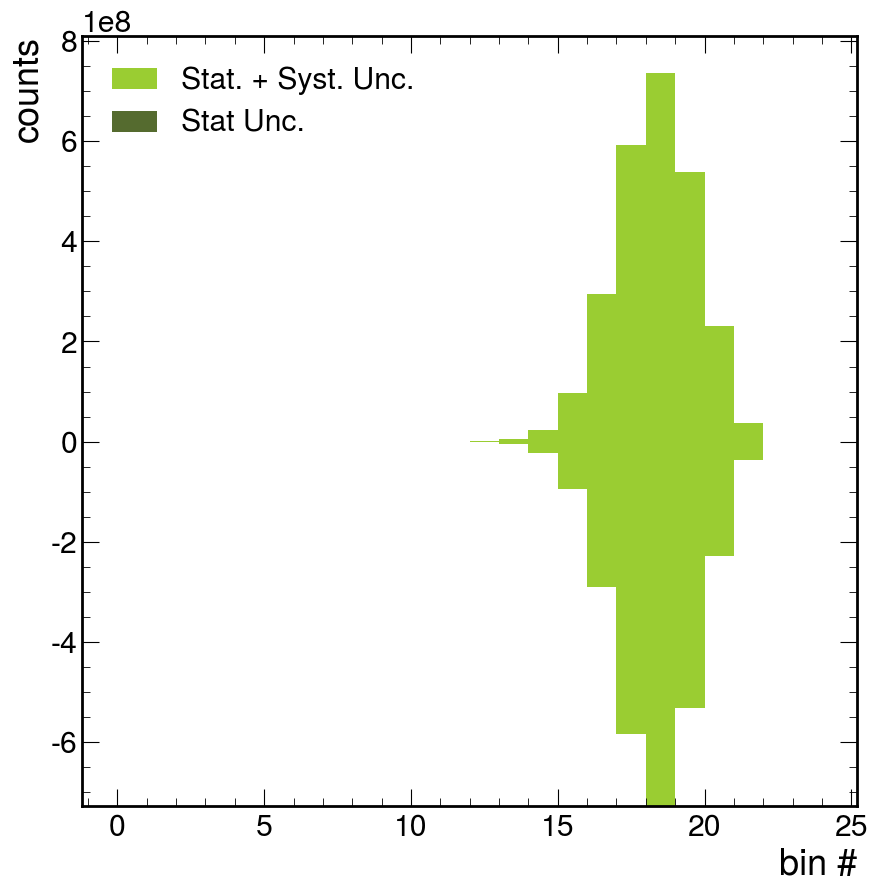

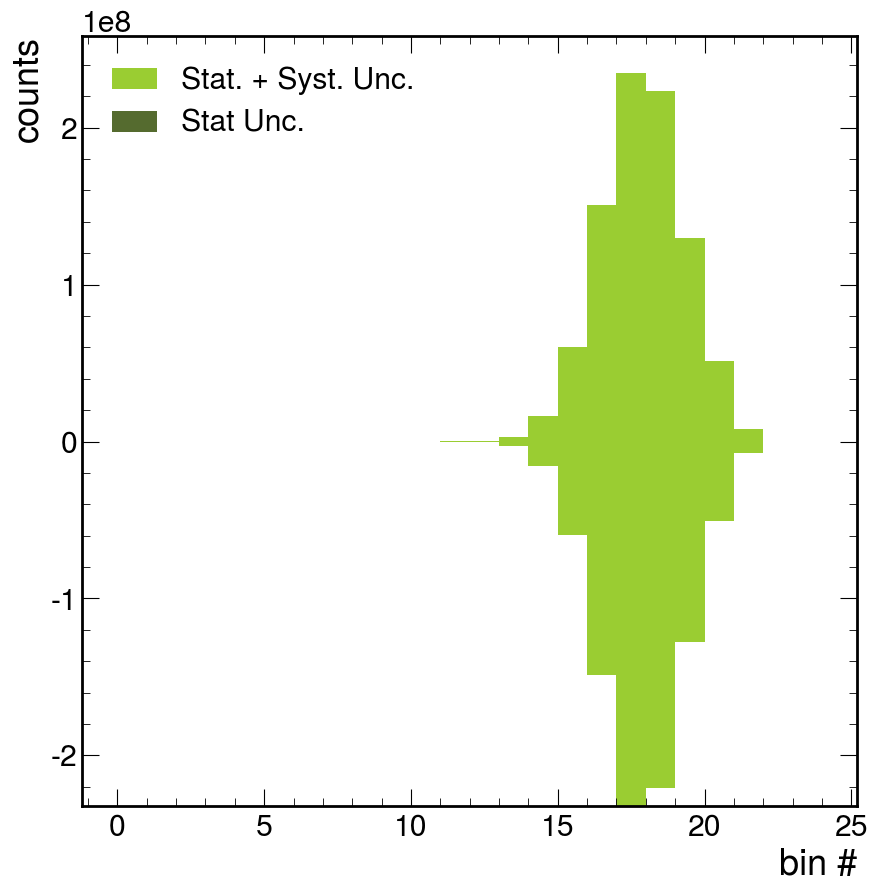

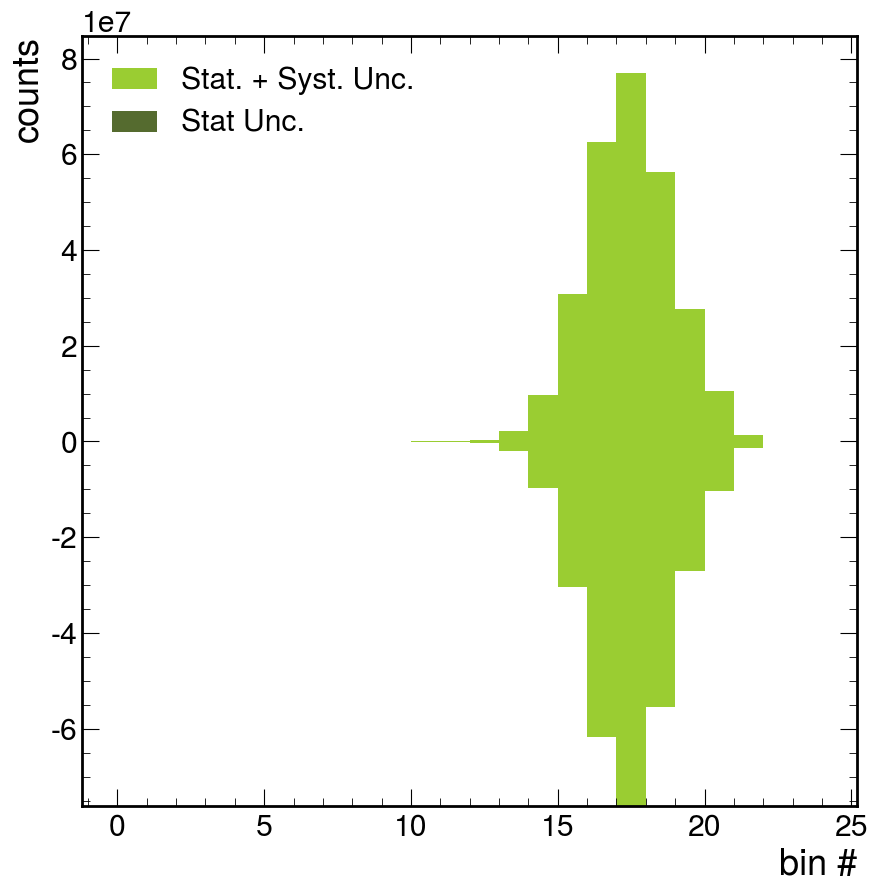

In [52]:
import matplotlib.pyplot as plt
import hist
import mplhep as hep
for i in range(4):
    mpt_reco_nom = m_nom.sum(axis = (0,1))[i]
    total_unc_up = np.zeros_like(mpt_reco_nom)
    total_stat = np.sqrt(variance.sum(axis = (0,1))[i])
    for key in sys_matrix_dic_up.keys():
        mpt_reco_sys = sys_matrix_dic_up[key].sum(axis = (0,1))[i] 
        delta = mpt_reco_sys - mpt_reco_nom
        total_unc_up += delta**2
    total_unc_up = np.sqrt(total_unc_up)
    total_unc_down = np.zeros_like(mpt_reco_nom)
    for key in sys_matrix_dic_down.keys():
        mpt_reco_sys = sys_matrix_dic_down[key].sum(axis = (0,1))[i] 
        delta = mpt_reco_sys - mpt_reco_nom
        total_unc_down += delta**2
    total_unc_down = np.sqrt(total_unc_down)
    bins = np.arange(len(mpt_reco_nom) + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    plt.style.use(hep.style.CMS)  # optional styling
    fig, ax = plt.subplots()
    hep.histplot(mpt_reco_nom, bins=bins, histtype='band', color='black',yerr=[total_unc_down, total_unc_up], label='Stat. + Syst. Unc.',ax=ax, facecolor = 'yellowgreen', hatch = '', alpha = 1)
    hep.histplot(mpt_reco_nom, bins=bins, histtype='band', color='black',yerr=[total_stat, total_stat], label='Stat Unc.',ax=ax, facecolor = 'darkolivegreen', hatch = '', alpha = 1)
    #ax.errorbar(bin_centers, mpt_reco_nom, yerr=[total_unc_down, total_unc_up], fmt='none', color='black', label='total uncertainty')
    #ax.set_yscale('log')
    ax.set_xlabel('bin #')
    ax.set_ylabel('counts')
    ax.legend()
    plt.show()

In [53]:
response[keymap['2018']][..., 'nominal'].project('ptgen', 'mpt_gen', 'ptreco', 'mpt_reco')

Hist(
  Variable([0, 200, 290, 400, 570, 760, 13000], name='ptgen'),
  Variable([-10, -6, -5, -4.5, -4, -3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0], name='mpt_gen'),
  Variable([0, 200, 290, 400, 570, 760, 13000], name='ptreco'),
  Variable(array([-10.  ,  -8.  ,  -6.  ,  -5.5 ,  -5.  ,  -4.75,  -4.5 ,  -4.25,
        -4.  ,  -3.75,  -3.5 ,  -3.25,  -3.  ,  -2.75,  -2.5 ,  -2.25,
        -2.  ,  -1.75,  -1.5 ,  -1.25,  -1.  ,  -0.75,  -0.5 ,  -0.25,
         0.  ]), name='mpt_reco'),
  storage=Weight()) # Sum: WeightedSum(value=6.72322e+06, variance=5.24444e+08)

LuminosityDown
PUSFDown
PDFDown
L1prefiringDown
nominal
herwigDown


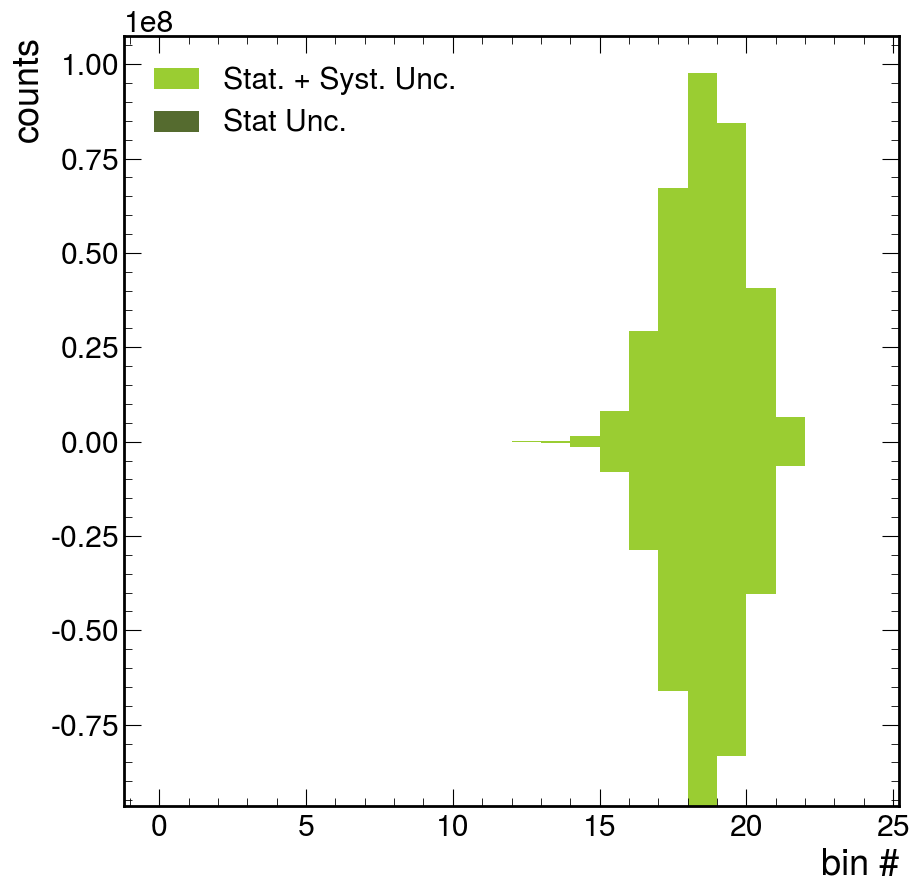

LuminosityDown
PUSFDown
PDFDown
L1prefiringDown
nominal
herwigDown


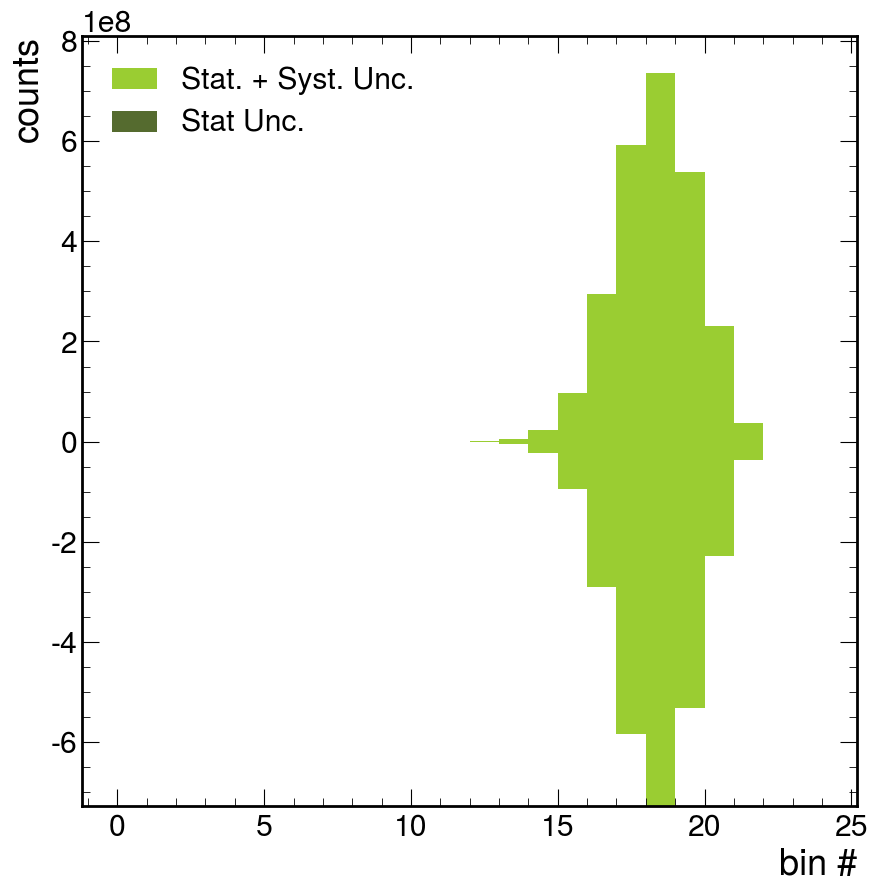

LuminosityDown
PUSFDown
PDFDown
L1prefiringDown
nominal
herwigDown


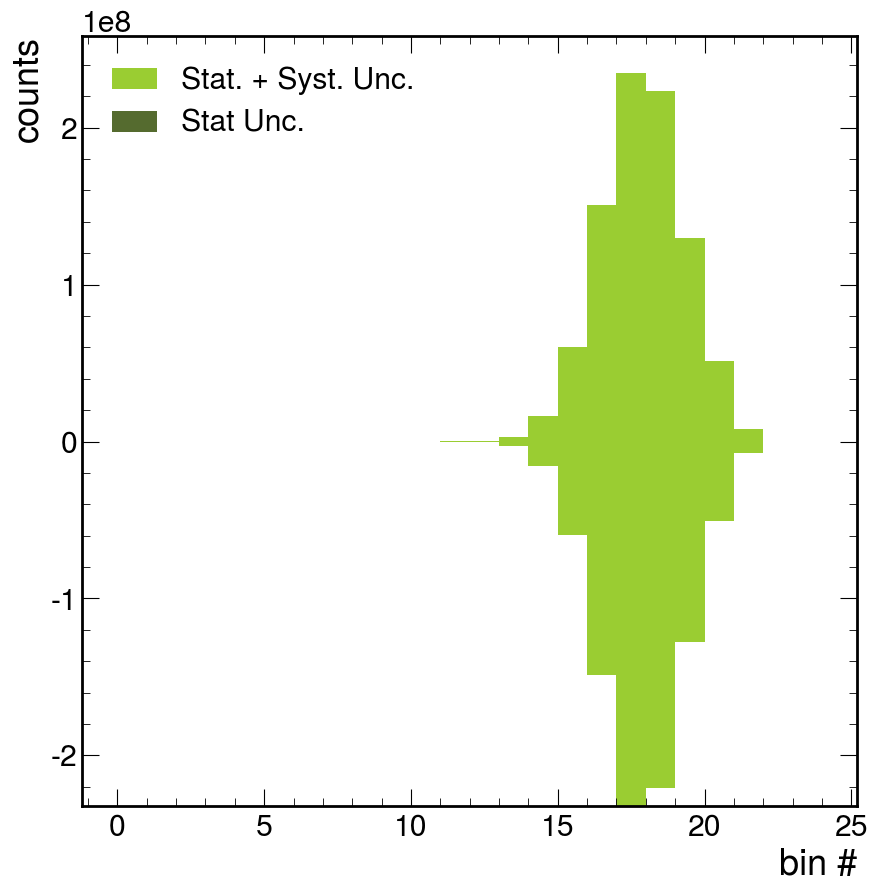

LuminosityDown
PUSFDown
PDFDown
L1prefiringDown
nominal
herwigDown


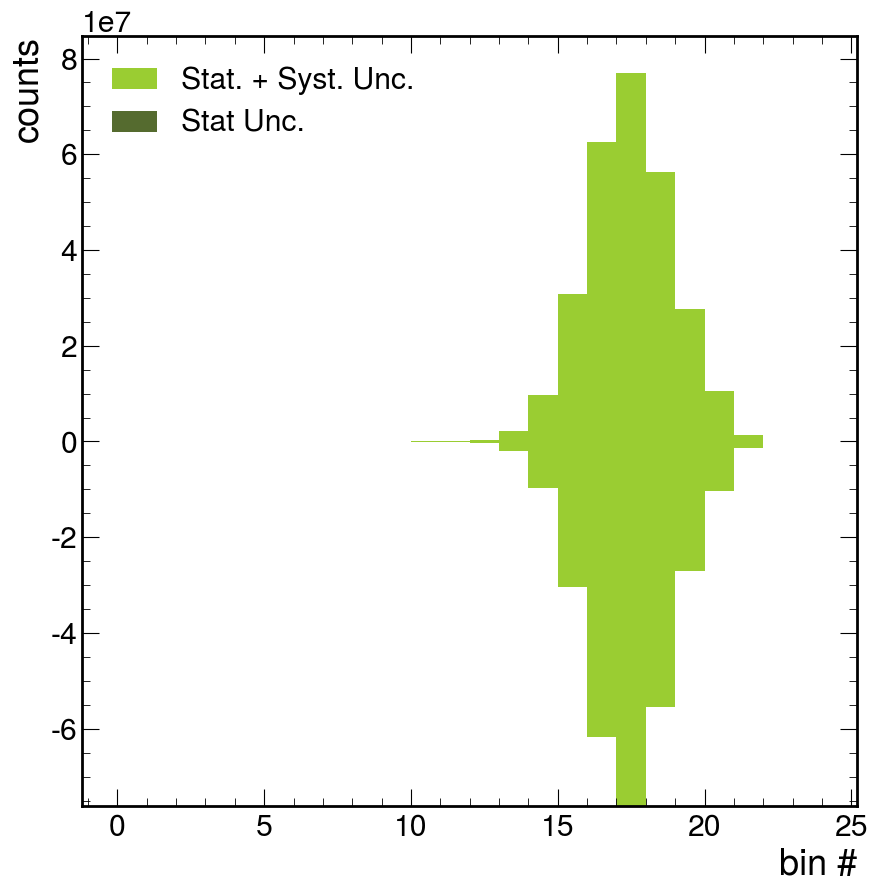

In [54]:
import matplotlib.pyplot as plt
import hist
import mplhep as hep
for i in range(4):
    mpt_reco_nom = m_nom.sum(axis = (0,1))[i]
    total_unc_up = np.zeros_like(mpt_reco_nom)
    total_stat = np.sqrt(variance.sum(axis = (0,1))[i])
    for key in sys_matrix_dic_up.keys():
        if key != "herwipUp":
            mpt_reco_sys = sys_matrix_dic_up[key].sum(axis = (0,1))[i] 
            delta = mpt_reco_sys - mpt_reco_nom
            total_unc_up += delta**2
    total_unc_up = np.sqrt(total_unc_up)
    total_unc_down = np.zeros_like(mpt_reco_nom)
    for key in sys_matrix_dic_down.keys():
        print(key)
        if key != "herwipDown":
            mpt_reco_sys = sys_matrix_dic_down[key].sum(axis = (0,1))[i] 
            delta = mpt_reco_sys - mpt_reco_nom
            total_unc_down += delta**2
    total_unc_down = np.sqrt(total_unc_down)
    bins = np.arange(len(mpt_reco_nom) + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    plt.style.use(hep.style.CMS)  # optional styling
    fig, ax = plt.subplots()
    hep.histplot(mpt_reco_nom, bins=bins, histtype='band', color='black',yerr=[total_unc_down, total_unc_up], label='Stat. + Syst. Unc.',ax=ax, facecolor = 'yellowgreen', hatch = '', alpha = 1)
    hep.histplot(mpt_reco_nom, bins=bins, histtype='band', color='black',yerr=[total_stat, total_stat], label='Stat Unc.',ax=ax, facecolor = 'darkolivegreen', hatch = '', alpha = 1)
    #ax.errorbar(bin_centers, mpt_reco_nom, yerr=[total_unc_down, total_unc_up], fmt='none', color='black', label='total uncertainty')
    #ax.set_yscale('log')
    ax.set_xlabel('bin #')
    ax.set_ylabel('counts')
    ax.legend()
    plt.show()